In [ ]:
!pip install torch torchvision matplotlib

In [ ]:
!wget http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2shoes.tar.gz
!tar -xvf edges2shoes.tar.gz

Streaming output truncated to the last 5000 lines.
edges2shoes/train/46382_AB.jpg
edges2shoes/train/46383_AB.jpg
edges2shoes/train/46384_AB.jpg
edges2shoes/train/46385_AB.jpg
edges2shoes/train/46386_AB.jpg
edges2shoes/train/46387_AB.jpg
edges2shoes/train/46388_AB.jpg
edges2shoes/train/46389_AB.jpg
edges2shoes/train/4638_AB.jpg
edges2shoes/train/46390_AB.jpg
edges2shoes/train/46391_AB.jpg
edges2shoes/train/46392_AB.jpg
edges2shoes/train/449_AB.jpg
edges2shoes/train/44_AB.jpg
edges2shoes/train/45000_AB.jpg
edges2shoes/train/45001_AB.jpg
edges2shoes/train/45002_AB.jpg
edges2shoes/train/45003_AB.jpg
edges2shoes/train/45004_AB.jpg
edges2shoes/train/45005_AB.jpg
edges2shoes/train/45006_AB.jpg
edges2shoes/train/45007_AB.jpg
edges2shoes/train/45008_AB.jpg
edges2shoes/train/45009_AB.jpg
edges2shoes/train/4500_AB.jpg
edges2shoes/train/45010_AB.jpg
edges2shoes/train/45011_AB.jpg
edges2shoes/train/45012_AB.jpg
edges2shoes/train/45013_AB.jpg
edges2shoes/train/45687_AB.jpg
edges2shoes/train/45688_AB

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

class Pix2PixDataset(Dataset):

    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.images = os.listdir(root_dir)

        self.transform = transforms.Compose([
            transforms.Resize((128,128)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        path = os.path.join(self.root_dir, self.images[idx])
        image = Image.open(path).convert("RGB")

        w,h = image.size

        edge = image.crop((0,0,w//2,h))
        real = image.crop((w//2,0,w,h))

        edge = self.transform(edge)
        real = self.transform(real)

        return edge, real

In [ ]:
train_dataset = Pix2PixDataset("edges2shoes/train")
test_dataset = Pix2PixDataset("edges2shoes/val")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=8)

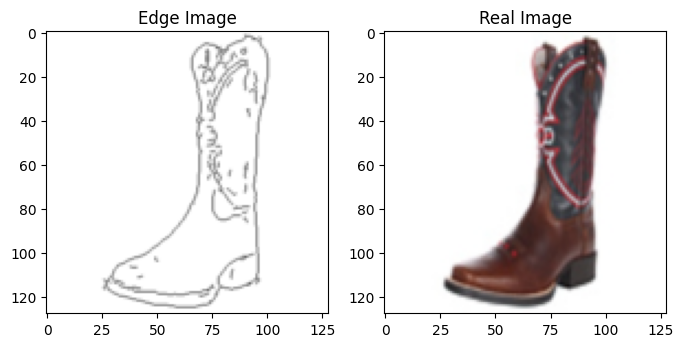

In [ ]:
edge, real = next(iter(train_loader))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Edge Image")
plt.imshow(edge[0].permute(1,2,0))

plt.subplot(1,2,2)
plt.title("Real Image")
plt.imshow(real[0].permute(1,2,0))

plt.show()

In [ ]:
class UNetGenerator(nn.Module):

    def __init__(self):
        super().__init__()

        def down(in_c,out_c):
            return nn.Sequential(
                nn.Conv2d(in_c,out_c,4,2,1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2)
            )

        def up(in_c,out_c):
            return nn.Sequential(
                nn.ConvTranspose2d(in_c,out_c,4,2,1),
                nn.BatchNorm2d(out_c),
                nn.ReLU()
            )

        self.d1 = down(3,64)
        self.d2 = down(64,128)
        self.d3 = down(128,256)
        self.d4 = down(256,512)

        self.u1 = up(512,256)
        self.u2 = up(512,128)
        self.u3 = up(256,64)

        self.final = nn.ConvTranspose2d(128,3,4,2,1)

    def forward(self,x):

        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)

        u1 = self.u1(d4)
        u1 = torch.cat([u1,d3],1)

        u2 = self.u2(u1)
        u2 = torch.cat([u2,d2],1)

        u3 = self.u3(u2)
        u3 = torch.cat([u3,d1],1)

        return torch.tanh(self.final(u3))

In [ ]:
class PatchDiscriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(6,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,1,4,1,1),
            nn.Sigmoid()
        )

    def forward(self,edge,img):

        x = torch.cat([edge,img],1)
        return self.model(x)

In [ ]:
class EncoderDecoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.ReLU(),

            nn.Conv2d(64,128,4,2,1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),

            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = UNetGenerator().to(device)
D = PatchDiscriminator().to(device)
CNN = EncoderDecoder().to(device)

In [ ]:
criterion_GAN = nn.BCELoss()
criterion_L1 = nn.L1Loss()

In [ ]:
optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5,0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5,0.999))

optimizer_CNN = optim.Adam(CNN.parameters(), lr=0.0002)

In [ ]:
epochs = 5

for epoch in range(epochs):

    for edge,real in train_loader:

        edge = edge.to(device)
        real = real.to(device)

        pred = CNN(edge)

        loss = criterion_L1(pred,real)

        optimizer_CNN.zero_grad()
        loss.backward()
        optimizer_CNN.step()

    print("CNN Epoch:",epoch,"Loss:",loss.item())

CNN Epoch: 0 Loss: 0.37714439630508423
CNN Epoch: 1 Loss: 0.25605612993240356
CNN Epoch: 2 Loss: 0.41510313749313354
CNN Epoch: 3 Loss: 0.2833768129348755
CNN Epoch: 4 Loss: 0.16084957122802734


In [ ]:
from tqdm import tqdm

epochs = 5

for epoch in range(epochs):

    loop = tqdm(train_loader, leave=True)

    for edge, real in loop:

        edge = edge.to(device)
        real = real.to(device)

        # Generate fake image
        fake_img = G(edge)

        # Discriminator prediction
        pred_real = D(edge, real)

        valid = torch.ones_like(pred_real)
        fake = torch.zeros_like(pred_real)

        # -----------------
        # Train Generator
        # -----------------

        pred_fake = D(edge, fake_img)

        loss_GAN = criterion_GAN(pred_fake, valid)
        loss_L1 = criterion_L1(fake_img, real)

        loss_G = loss_GAN + 100 * loss_L1

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        # -----------------
        # Train Discriminator
        # -----------------

        loss_real = criterion_GAN(pred_real, valid)

        pred_fake = D(edge, fake_img.detach())
        loss_fake = criterion_GAN(pred_fake, fake)

        loss_D = (loss_real + loss_fake) / 2

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # Update progress bar
        loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
        loop.set_postfix(
            G_Loss=loss_G.item(),
            D_Loss=loss_D.item()
        )

Epoch [5/5]: 100%|██████████| 1558/1558 [04:45<00:00,  5.45it/s, D_Loss=0.76, G_Loss=12.3]


In [ ]:
edge,real = next(iter(test_loader))

edge = edge.to(device)

with torch.no_grad():

    cnn_out = CNN(edge)
    gan_out = G(edge)

edge = edge.cpu()
cnn_out = cnn_out.cpu()
gan_out = gan_out.cpu()
real = real.cpu()

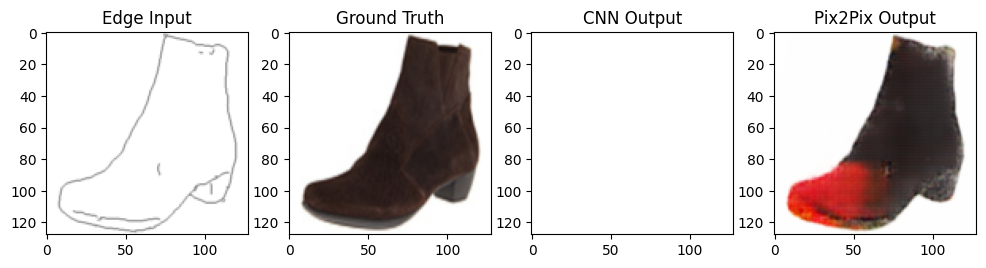

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.title("Edge Input")
plt.imshow(edge[0].permute(1,2,0))

plt.subplot(1,4,2)
plt.title("Ground Truth")
plt.imshow(real[0].permute(1,2,0))

plt.subplot(1,4,3)
plt.title("CNN Output")
plt.imshow(cnn_out[0].permute(1,2,0))

plt.subplot(1,4,4)
plt.title("Pix2Pix Output")
plt.imshow(gan_out[0].permute(1,2,0))

plt.show()